In [1164]:
import cv2
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = Path().resolve().parent / 'data'
BBDD_DIR = DATA_DIR / 'BBDD'
QSD2 = DATA_DIR / 'qsd2_w2'

IMG_ID = '00028'

In [1165]:
def show(*images, titles=None, size=3, cols=4):
    cols = min(cols, len(images))
    rows = -(-len(images) // cols)
    fig, axes = plt.subplots(rows, cols, figsize=(size * cols, size * rows), squeeze=False)
    for ax in axes.flat[len(images):]:
        ax.axis('off')
    for i, (ax, im) in enumerate(zip(axes.flat, images)):
        if im.ndim == 2:
            ax.imshow(im, cmap='gray', vmin=0, vmax=255)
        else:
            ax.imshow(im)
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_color('blue')
            spine.set_linewidth(1.5)
        if titles:
            ax.set_title(titles[i])
    plt.tight_layout()
    plt.show()

def norm(img):
    return cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)

def inv(img):
    return 255 - norm(img)

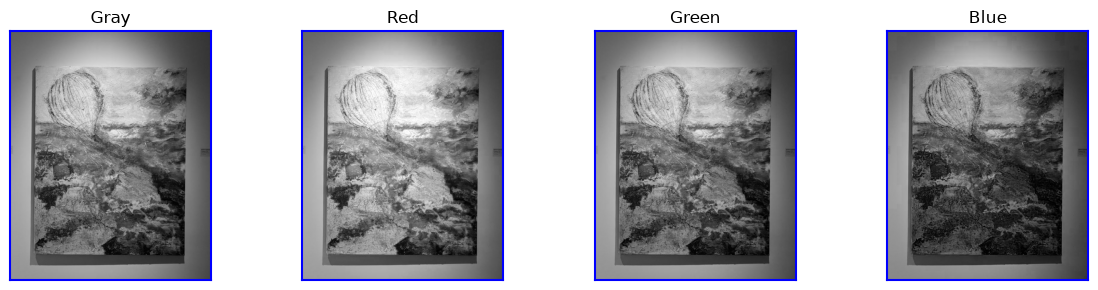

In [1166]:
img = cv2.imread(QSD2 / (IMG_ID + '.jpg'))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
r, g, b = img[:,:,0], img[:,:,1], img[:,:,2]
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

h, w = gray.shape

show(gray, r, g, b, titles=['Gray', 'Red', 'Green', 'Blue'])

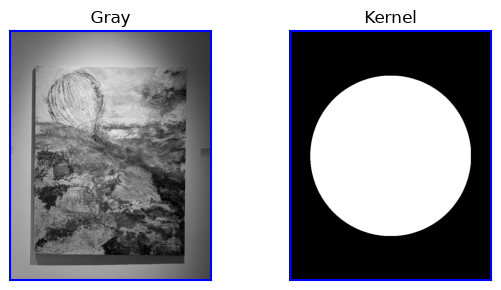

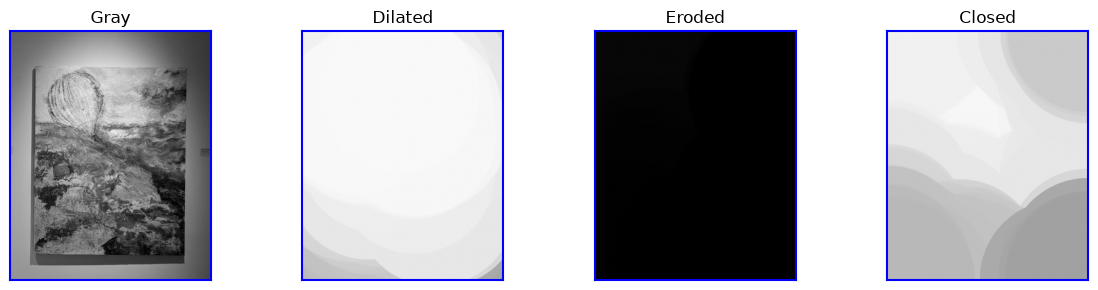

In [1167]:
n = int(min(h,w) * 0.8)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (n,n))

y0 = h // 2 - n // 2
x0 = w // 2 - n // 2
empty = np.zeros_like(gray)
empty[y0:y0 + n, x0:x0 + n] = kernel * 255

show(gray, empty, titles=['Gray', 'Kernel'])

dilated = cv2.dilate(gray, kernel)
eroded = cv2.erode(gray, kernel)
closed = cv2.morphologyEx(gray, cv2.MORPH_CLOSE, kernel)

show(gray, dilated, eroded, closed, titles=['Gray', 'Dilated', 'Eroded', 'Closed'])

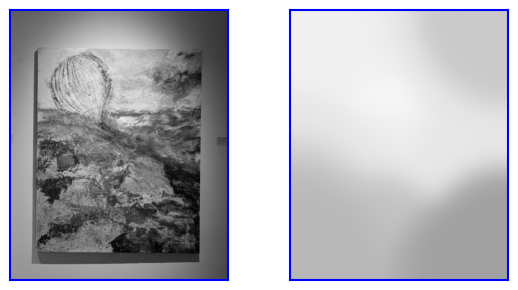

In [1168]:
n = int(min(h,w)//3)
n = n + 1 if n % 2 == 0 else n

back = cv2.GaussianBlur(closed, (n, n), 0)
show(gray, back)

In [1169]:
# gray = gray.astype(np.int16)
# back = back.astype(np.int16)

# correction = gray[0][0] - back[0][0] + gray[h-1][w-1] - back[h-1][w-1] + gray[0][w-1] - back[0][w-1] + gray[h-1][0] - back[h-1][0]
# correction = correction // 4
# back = back + correction

# show(gray, back)

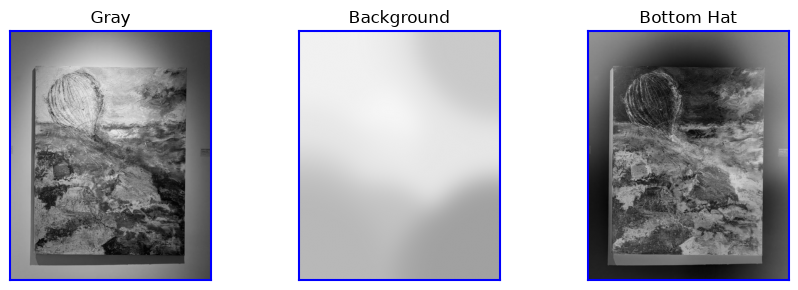

In [1170]:
bottom_hat = cv2.absdiff(back, gray)
bottom_hat = np.clip(bottom_hat, 0, 255).astype(np.uint8)

show(gray, back, bottom_hat, titles=['Gray', 'Background', 'Bottom Hat'])

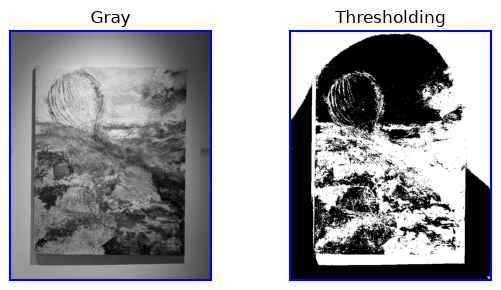

In [1171]:
t, thr = cv2.threshold(bottom_hat, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
show(gray, norm(thr), titles=['Gray', 'Thresholding'])

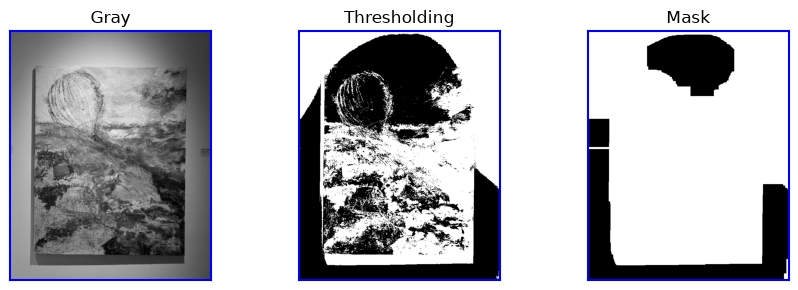

In [1172]:
n = min(h,w)//10
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (n,n))

mask = cv2.morphologyEx(thr, cv2.MORPH_CLOSE, kernel)
show(gray, thr, mask, titles=['Gray', 'Thresholding', 'Mask'])

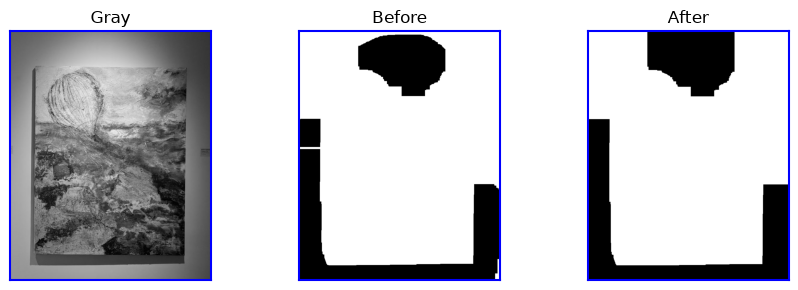

In [1173]:
n = min(h,w)//5
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (n,n))

last_mask = mask.copy()
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
show(gray, last_mask, mask, titles=['Gray', 'Before', 'After'])

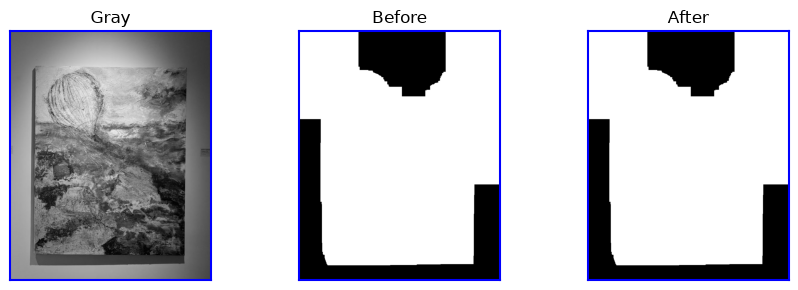

In [1174]:
n = int(min(h,w)/10)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (n,n))

last_mask = mask.copy()
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

show(gray, last_mask, mask, titles=['Gray', 'Before', 'After'])

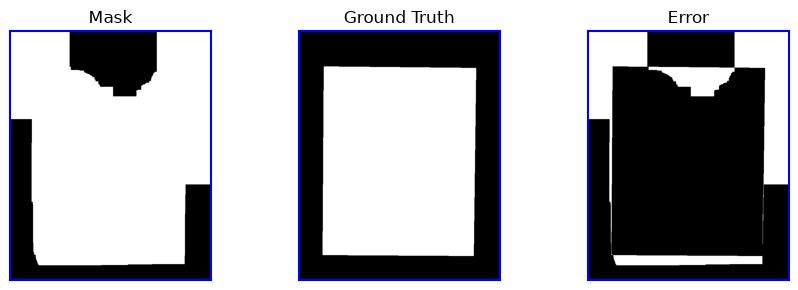

In [1175]:
gt = cv2.imread(QSD2 / (IMG_ID+'.png'), cv2.IMREAD_GRAYSCALE)

err = cv2.absdiff(mask, gt)

show(mask, gt, err, titles=['Mask', 'Ground Truth', 'Error'])